In [2]:
import pandas as pd
import numpy as np
import pickle, os
from matplotlib import pyplot as plt
from tqdm import tqdm

In [3]:
class Data:
    def __init__(self, array_list):
        self.array_list = array_list

    def save(self, filename):
        with open(filename, 'wb') as f:
            pickle.dump(self.array_list, f)

    @classmethod
    def load(cls, filename):
        with open(filename, 'rb') as f:
            array_list = pickle.load(f)
        return cls(array_list)

In [61]:
omegas_file = 'ct_data_omg/timeomega.dat'

with open(omegas_file, 'r') as f:
    # Count total lines minus comment lines
    total_rows = sum(1 for line in f if not line.startswith('#'))

# Now, use `skiprows` to skip rows directly in pandas, excluding indices for FIELDS and comments
df = pd.read_csv(
    omegas_file,
    delim_whitespace=True
#    names=columns
    #skiprows=skip_every_20th(1, total_rows)  # Start after '#! FIELDS' line
)

# Display the DataFrame
df

,time,omega1,omega2,omega3
0,0.02,2.920844,2.893401,3.098204
1,0.42,2.260316,-2.611256,2.729368
2,0.82,3.064625,-2.870014,-3.013302
3,1.22,2.873185,3.028340,3.049154
4,1.62,-3.065443,-3.050443,2.147561
...,...,...,...,...
2753844,1082590.20,-2.215501,-0.271389,2.841058
2753845,1082590.22,-2.166989,-0.302004,2.749883
2753846,1082590.24,-2.152898,-0.106235,2.756301
2753847,1082590.26,-2.141612,-0.315658,2.859370


In [62]:
# Extract the omegas 
omega_df = df[['omega1', 'omega2', 'omega3']]
# omega_df.astype(float)
omega_np = omega_df.to_numpy()
omega_np.shape

(2753849, 3)

In [63]:
def omega2cistrans(omega):
    """Converts a sequence of float omega angles (in degrees) to an array of ints: 0 cis and 1 trans."""
    
    shifted_omega = (omega + 90.0) % 360.0 - 90.0 # shift into (-90, 270) range to avoid periodic boundaries
    
    cistrans = np.where(shifted_omega > 90.0, 1, 0).astype(int)
    return cistrans

# Convert the radians to angles
omega_angle = omega_np * (180 / np.pi)
omega_angle

array([[ 167.35203382,  165.77966574,  177.51401327],
       [ 129.50656717, -149.61394803,  156.38126714],
       [ 175.59007829, -164.43968934, -172.649487  ],
       ...,
       [-123.35196912,   -6.08681714,  157.92441437],
       [-122.70532895,  -18.08587117,  163.82983307],
       [-129.94373396,   -8.09744063,  156.07444824]])

In [64]:
all_cistrans = omega2cistrans(omega_angle)
all_cistrans.shape
# Find the minimum x-dimension across all arrays
min_x = min(arr.shape[0] for arr in all_cistrans)

print(f"Shortest x in all_cistrans: {min_x}")

Shortest x in all_cistrans: 3


In [65]:
def state_to_index_simple(all_cistrans):
    """Converts a (N, 3) binary array into decimal indices in [0..7]."""
    all_cistrans = np.array(all_cistrans)  # Ensure it's a numpy array
    if all_cistrans.shape[1] != 3:
        raise ValueError(f"Unexpected shape: {all_cistrans.shape}, expected (N, 3).")
    # Binary weights for [a, b, c] => 4a + 2b + c
    weights = np.array([4, 2, 1])
    states = all_cistrans @ weights  # Dot product to calculate state indices
    # Combine original states with indices for output
    new_all = np.column_stack((all_cistrans, states))
    return new_all

def index_to_state_simple(index):
    """Converts an index (0-31) into a (4,) array where:
       - The first three entries are binary bits (0 or 1),
       - The last entry is in [0..3].
    """
    # Validate the input range
    if not (0 <= index < 32):
        raise ValueError(f"Index out of range: {index}. Expected 0-31.")
    
    # Last part (x): remainder when dividing by 4
    last_part = index % 4
    
    # First three bits (a, b, c): integer division by 4 (binary form in [0..7])
    first_3_bits = np.array([(index // 4) >> i & 1 for i in reversed(range(3))], dtype=int)
    
    # Combine the binary bits and the last part
    state = np.concatenate([first_3_bits, [last_part]])
    
    return state

def get_transition_matrix_single_trajectory(n_traj, num_states, lagtime, pseudocount=0.25):
    """
    Compute the transition matrix for a single trajectory.
    
    Parameters
    ----------
    n_traj : ndarray
        A single trajectory of states (array of shape `(L,)`, where `L` is the length of the trajectory).
    num_states : int
        The total number of states expected.
    lagtime : int
        The lag time for the transition matrix computation.
    pseudocount : float, optional
        Value added to prevent zero counts in the matrix (default is 0.25).
    
    Returns
    -------
    T : ndarray
        A `(num_states, num_states)` transition matrix.
    """
#     # Ensure `n_traj` is actually a single trajectory, i.e., a 1D array
#     if not isinstance(n_traj, np.ndarray) or n_traj.ndim != 1:
#         raise ValueError(f"n_traj must be a 1D array. Got shape: {n_traj.shape if isinstance(n_traj, np.ndarray) else 'Non-array'}")

    # Compute the transition matrix for the single trajectory
    T = compute_transition_matrix([n_traj], num_states=num_states, lagtime=lagtime, pseudocount=pseudocount)

    # Ensure the resulting matrix is valid and has the correct shape
    if not isinstance(T, np.ndarray) or T.shape != (num_states, num_states):
        raise ValueError(f"Transition matrix must be of shape ({num_states}, {num_states}). Got shape: {T.shape if isinstance(T, np.ndarray) else 'Non-array'}")
    
    return T

def compute_stationary_distribution(T, lagtime):
    """Compute the stationary distribution of a transition matrix T.
    
    INPUT:
    T - Transition matrix where T_ij is the probability of transitioning i -> j.
    
    RETURN:
    pi - The stationary distribution (1D NumPy array).
    t2 - The implied timescale (in units of steps).
    """
    try:
        # Compute the implied timescale
        evals = np.linalg.eigvals(T.transpose() )  # will be something like [0.99754545 1.        ]
        evals_sorted = np.sort(evals)      # ascending order
        mu2 = evals_sorted[-2]            # second-largest eigenvalue
        #print('mu2', mu2, 'evals', evals, 'evals_sorted', evals_sorted, 'T', T)
        
        t2 = -1.0*lagtime/np.log(mu2.real)  # the implied timescale relation
        #print('evals_sorted', evals_sorted, 'mu2', mu2, 't2', t2)

        # Compute the stationary state distribution 
        n_states = T.shape[0]
        A = np.transpose(T) - np.eye(n_states)  # (T' - I)
        A = np.vstack([A, np.ones(n_states)])  # Append normalization row
        b = np.zeros(n_states + 1)
        b[-1] = 1  # Ensure probability sums to 1
        
        # Solve for stationary distribution using least squares
        pi, *_ = np.linalg.lstsq(A, b, rcond=None)
        
        # Ensure non-negative values and normalize
        pi = np.maximum(pi, 0)  # Prevent small negative values due to numerical error
        pi /= np.sum(pi)  # Normalize to sum to 1

    except Exception as e:
        print(f"Error computing stationary distribution: {e}")
        t2 = np.nan
        pi = None

    return pi, t2

In [66]:
ntraj = len(all_cistrans)
print(ntraj)

# Find the longest traj
maxlength = max( [ len(all_cistrans[i]) for i in range(ntraj) ])
print('maxlength', maxlength)

# # Make an array to store all the trajectories
# traj = np.nan * np.ones( (ntraj, maxlength, 4) )

# for i in range(ntraj):
#     n = len(all_cistrans[i])
#     traj[i, 0:n, :] = all_cistrans[i]

# traj
traj = all_cistrans
# Step 1: Convert to indexed states
traj_indexed = state_to_index_simple(traj)  # Convert `[a, b, c]` to integer indices
print("Indexed Trajectory:", traj_indexed)

# Step 2: Compute transition matrix
# Wrap the trajectory as a list because `compute_transition_matrix` expects `[trajectory]`
num_states = 8  # Total number of possible states from `[a, b, c]` (2^3 = 8)
lagtime = 1
# transition_matrix = get_transition_matrix_single_trajectory([traj_indexed], num_states=num_states, lagtime=lagtime)

# print("Transition Matrix:")
# print(transition_matrix)
print('traj_indexed.shape', traj_indexed.shape)
print('traj.shape', traj.shape)

2753849
maxlength 3
Indexed Trajectory: [[1 1 1 7]
 [1 1 1 7]
 [1 1 1 7]
 ...
 [1 0 1 5]
 [1 0 1 5]
 [1 0 1 5]]
traj_indexed.shape (2753849, 4)
traj.shape (2753849, 3)


In [67]:
final_column = traj_indexed[:, -1]  # Shape (120000,)

# Reshape into a matrix with shape (1, 120000)
traj_real = final_column.reshape(1, -1)
print('traj_real.shape', traj_real.shape)
traj_real

traj_real.shape (1, 2753849)


array([[7, 7, 7, ..., 5, 5, 5]])

In [68]:
# Updated parameters for your single trajectory
# traj_indexed = your_trajectory_data  # Shape (1, 200000)
num_states = 8 
lagtimes = [5, 10, 25, 50] + list(range(100, 1000000, 5000))
dt_in_ns = 0.0004
n_bootstrap_samples = 1  # Number of bootstrap samples to create from your single trajectory

# Store results (same as before)
pi_all_means = []
pi_all_uppers = []
pi_all_lowers = []
pi_all_stds = []
t2_all_means = []
t2_all_uppers = []
t2_all_lowers = []
t2_all_stds = []




def process_single_trajectory(traj_indexed, lagtime, num_states, n_bootstrap_samples):
    """Process single trajectory by creating bootstrap samples from segments"""
    
    # Get the single trajectory
    single_traj = traj_indexed[0]  # Shape: (200000,)
    
    # Create bootstrap samples by taking random segments
    transition_matrices = get_bootstrap_transition_matrices(
        single_traj, num_states, lagtime, n_bootstrap_samples, pseudocount=0.25
    )
    
    # Calculate the stationary population
    pi_all = []
    t2_all = []
    
    for T in transition_matrices:
        pi, t2 = compute_stationary_distribution(T, lagtime)
        pi_all.append(pi)
        t2_all.append(t2)
    
    pi_all = np.array(pi_all)
    t2_all = np.array(t2_all)
    
    # Handle t2 statistics (geometric mean and std)
    log_t2_all = [np.log(t2) for t2 in t2_all if t2 > 0]
    if log_t2_all:
        t2_mean = np.exp(np.mean(log_t2_all))
        t2_std = np.exp(np.sqrt(np.var(log_t2_all)))
    else:
        t2_mean = 0
        t2_std = 0
    
    pi_means = np.mean(pi_all, axis=0)  # Mean across bootstrap samples
    pi_std = np.std(pi_all, axis=0)     # Standard deviation
    
    return pi_means, pi_std, t2_mean, t2_std


def get_bootstrap_transition_matrices(single_traj, num_states, lagtime, n_bootstrap_samples, pseudocount=0.25):
    """
    Create bootstrap samples from a single trajectory by taking random segments
    """
    traj_length = len(single_traj)
    
    # Calculate segment length (ensure we have enough data for meaningful statistics)
    # Use segments that are long enough but allow for overlap
    segment_length = max(10000, traj_length )#// (n_bootstrap_samples // 2))  # Allow overlap
    segment_length = min(segment_length, traj_length - lagtime)
    
    transition_matrices = []
    
    for i in range(n_bootstrap_samples):
        # Randomly select start position for this bootstrap sample
        max_start = traj_length - segment_length
        if max_start <= 0:
            # If trajectory is too short, use the whole trajectory
            start_idx = 0
            end_idx = traj_length
        else:
            start_idx = np.random.randint(0, max_start)
            end_idx = start_idx + segment_length
        
        # Extract segment
        segment = single_traj[start_idx:end_idx]
        
        # Compute transition matrix for this segment
        T = compute_transition_matrix_single(segment, num_states, lagtime, pseudocount)
        
        # Debug check
        if not isinstance(T, np.ndarray) or T.ndim != 2:
            print(f"[ERROR] compute_transition_matrix_single returned invalid type/shape: {type(T)}, shape={getattr(T, 'shape', None)}")
            raise ValueError("Transition matrix must be a 2D array")
        
        transition_matrices.append(T)
    
    return transition_matrices


def compute_transition_matrix_single(segment, num_states, lagtime, pseudocount=0.25):
    """Compute transition matrix for a single trajectory segment."""
    
    C = np.zeros((num_states, num_states))  # Initialize count matrix
    
    for t in range(len(segment) - lagtime):
        from_state = segment[t]
        to_state = segment[t + lagtime]
        
        # Skip NaN transitions
        if np.isnan(from_state) or np.isnan(to_state):
            continue
            
        # Convert states to integers for indexing
        from_state = int(from_state)
        to_state = int(to_state)
        
        # Ensure states are within valid range
        if 0 <= from_state < num_states and 0 <= to_state < num_states:
            C[from_state, to_state] += 1.0
    
    # Add pseudocounts to avoid zero entries
    C += pseudocount
    
    # Normalize rows to get probabilities
    row_sums = C.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1  # Prevent division by zero
    T = C / row_sums
    
    return T

In [69]:
# Extract individual residue trajectories
res1_traj = traj_indexed[:, 0].reshape(1, -1)  # Shape: (1, 205058)
res2_traj = traj_indexed[:, 1].reshape(1, -1)  # Shape: (1, 205058)  
res3_traj = traj_indexed[:, 2].reshape(1, -1)  # Shape: (1, 205058)

# Parameters for individual residues
num_states_per_residue = 2  # Binary states (0, 1)
residue_names = ['res1', 'res2', 'res3']
residue_trajs = [res1_traj, res2_traj, res3_traj]

# Store results for each residue
residue_results = {}

for res_name, res_traj in zip(residue_names, residue_trajs):
    print(f"Processing {res_name}...")
    
    # Initialize storage for this residue
    pi_all_means = []
    pi_all_stds = []
    t2_all_means = []
    t2_all_stds = []
    
    # Process each lagtime for this residue
    for lagtime in tqdm(lagtimes, desc=f"Processing {res_name}", unit="lag"):
        pi_means, pi_std, t2_mean, t2_std = process_single_trajectory(
            res_traj, lagtime, num_states_per_residue, n_bootstrap_samples
        )
        
        pi_all_means.append(pi_means)
        pi_all_stds.append(pi_std)
        t2_all_means.append(t2_mean)
        t2_all_stds.append(t2_std)
    
    # Store results for this residue
    residue_results[res_name] = {
        'pi_means': np.array(pi_all_means),  # Shape: (n_lagtimes, 2)
        'pi_stds': np.array(pi_all_stds),    # Shape: (n_lagtimes, 2)
        't2_means': np.array(t2_all_means),  # Shape: (n_lagtimes,)
        't2_stds': np.array(t2_all_stds)     # Shape: (n_lagtimes,)
    }
    
    print(f"{res_name} pi_means shape: {residue_results[res_name]['pi_means'].shape}")

Processing res1...


Processing res1:   2%|▏         | 5/204 [00:20<13:32,  4.08s/lag]<ipython-input-65-ba77b707300b>:83: RuntimeWarning: invalid value encountered in log
  t2 = -1.0*lagtime/np.log(mu2.real)  # the implied timescale relation
Processing res1: 100%|██████████| 204/204 [08:56<00:00,  2.63s/lag]


res1 pi_means shape: (204, 2)
Processing res2...


Processing res2: 100%|██████████| 204/204 [08:55<00:00,  2.63s/lag]


res2 pi_means shape: (204, 2)
Processing res3...


Processing res3: 100%|██████████| 204/204 [08:56<00:00,  2.63s/lag]

res3 pi_means shape: (204, 2)


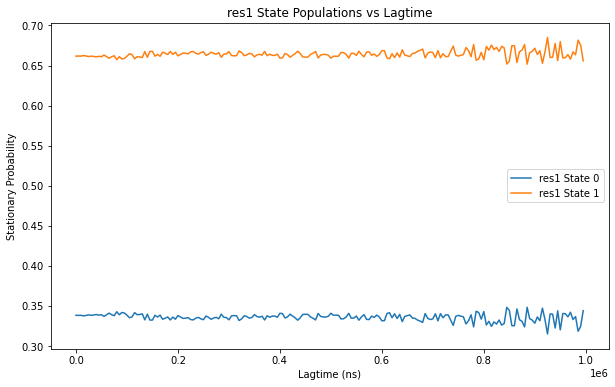

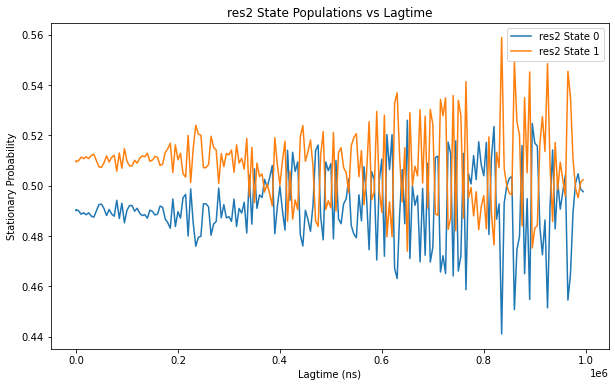

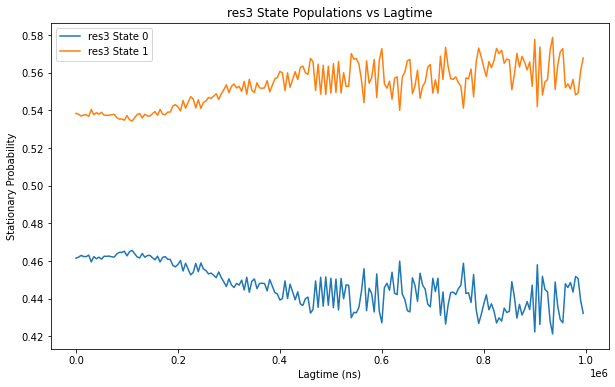

In [70]:
# For residue 1
res1_pi_state0 = residue_results['res1']['pi_means'][:, 0]  # Probability of state 0
res1_pi_state1 = residue_results['res1']['pi_means'][:, 1]  # Probability of state 1
res1_t2 = residue_results['res1']['t2_means']               # Relaxation times
lagtime_ns = lagtimes
# Plot individual residue behavior
for res_name in residue_names:
    plt.figure(figsize=(10, 6))
    plt.plot(lagtimes, residue_results[res_name]['pi_means'][:, 0], label=f'{res_name} State 0')
    plt.plot(lagtimes, residue_results[res_name]['pi_means'][:, 1], label=f'{res_name} State 1')
    plt.xlabel('Lagtime (ns)')
    plt.ylabel('Stationary Probability')
    plt.title(f'{res_name} State Populations vs Lagtime')
    plt.legend()
    plt.show()

In [71]:
# Combine all residues into arrays matching your original format
all_residues_pi_means = []
all_residues_pi_stds = []
all_residues_t2_means = []
all_residues_t2_stds = []

for res_name in residue_names:
    all_residues_pi_means.append(residue_results[res_name]['pi_means'])
    all_residues_pi_stds.append(residue_results[res_name]['pi_stds'])
    all_residues_t2_means.append(residue_results[res_name]['t2_means'])
    all_residues_t2_stds.append(residue_results[res_name]['t2_stds'])

# Convert to arrays: shape (n_residues, n_lagtimes, n_states) for pi
all_residues_pi_means = np.array(all_residues_pi_means)  # (3, n_lagtimes, 2)
all_residues_pi_stds = np.array(all_residues_pi_stds)    # (3, n_lagtimes, 2)
all_residues_t2_means = np.array(all_residues_t2_means)  # (3, n_lagtimes)
all_residues_t2_stds = np.array(all_residues_t2_stds)    # (3, n_lagtimes)

# Calculate uppers/lowers
pi_uppers = all_residues_pi_means + all_residues_pi_stds
pi_lowers = all_residues_pi_means - all_residues_pi_stds
t2_uppers = all_residues_t2_means + all_residues_t2_stds
t2_lowers = all_residues_t2_means - all_residues_t2_stds

# Save in same format as before
data_instance = Data([
    all_residues_pi_means, pi_uppers, pi_lowers, all_residues_pi_stds,
    all_residues_t2_means, t2_uppers, t2_lowers, all_residues_t2_stds,
    lagtime_ns, residue_names
])

data_instance.save("autocoorel_data_omg/stationary_distribution_res_nobs.pkl")


In [72]:
# Updated parameters for your single trajectory
# traj_indexed = your_trajectory_data  # Shape (1, 200000)
num_states = 8 
lagtimes = [5, 10, 25, 50] + list(range(100, 1000000, 5000))
dt_in_ns = 0.0004
n_bootstrap_samples = 10  # Number of bootstrap samples to create from your single trajectory

# Store results (same as before)
pi_all_means = []
pi_all_uppers = []
pi_all_lowers = []
pi_all_stds = []
t2_all_means = []
t2_all_uppers = []
t2_all_lowers = []
t2_all_stds = []


# Extract individual residue trajectories
res1_traj = traj_indexed[:, 0].reshape(1, -1)  # Shape: (1, 205058)
res2_traj = traj_indexed[:, 1].reshape(1, -1)  # Shape: (1, 205058)  
res3_traj = traj_indexed[:, 2].reshape(1, -1)  # Shape: (1, 205058)

# Parameters for individual residues
num_states_per_residue = 2  # Binary states (0, 1)
residue_names = ['res1', 'res2', 'res3']
residue_trajs = [res1_traj, res2_traj, res3_traj]

# Store results for each residue
residue_results = {}

for res_name, res_traj in zip(residue_names, residue_trajs):
    print(f"Processing {res_name}...")
    
    # Initialize storage for this residue
    pi_all_means = []
    pi_all_stds = []
    t2_all_means = []
    t2_all_stds = []
    
    # Process each lagtime for this residue
    for lagtime in tqdm(lagtimes, desc=f"Processing {res_name}", unit="lag"):
        pi_means, pi_std, t2_mean, t2_std = process_single_trajectory(
            res_traj, lagtime, num_states_per_residue, n_bootstrap_samples
        )
        
        pi_all_means.append(pi_means)
        pi_all_stds.append(pi_std)
        t2_all_means.append(t2_mean)
        t2_all_stds.append(t2_std)
    
    # Store results for this residue
    residue_results[res_name] = {
        'pi_means': np.array(pi_all_means),  # Shape: (n_lagtimes, 2)
        'pi_stds': np.array(pi_all_stds),    # Shape: (n_lagtimes, 2)
        't2_means': np.array(t2_all_means),  # Shape: (n_lagtimes,)
        't2_stds': np.array(t2_all_stds)     # Shape: (n_lagtimes,)
    }
    
    print(f"{res_name} pi_means shape: {residue_results[res_name]['pi_means'].shape}")

Processing res1...


Processing res1:   2%|▏         | 5/204 [03:23<2:15:08, 40.75s/lag]<ipython-input-65-ba77b707300b>:83: RuntimeWarning: invalid value encountered in log
  t2 = -1.0*lagtime/np.log(mu2.real)  # the implied timescale relation
Processing res1: 100%|██████████| 204/204 [1:29:18<00:00, 26.27s/lag]


res1 pi_means shape: (204, 2)
Processing res2...


Processing res2: 100%|██████████| 204/204 [12:29:45<00:00, 220.52s/lag]    


res2 pi_means shape: (204, 2)
Processing res3...


Processing res3: 100%|██████████| 204/204 [8:59:39<00:00, 158.72s/lag]    

res3 pi_means shape: (204, 2)


In [73]:
# Combine all residues into arrays matching your original format
all_residues_pi_means = []
all_residues_pi_stds = []
all_residues_t2_means = []
all_residues_t2_stds = []

for res_name in residue_names:
    all_residues_pi_means.append(residue_results[res_name]['pi_means'])
    all_residues_pi_stds.append(residue_results[res_name]['pi_stds'])
    all_residues_t2_means.append(residue_results[res_name]['t2_means'])
    all_residues_t2_stds.append(residue_results[res_name]['t2_stds'])

# Convert to arrays: shape (n_residues, n_lagtimes, n_states) for pi
all_residues_pi_means = np.array(all_residues_pi_means)  # (3, n_lagtimes, 2)
all_residues_pi_stds = np.array(all_residues_pi_stds)    # (3, n_lagtimes, 2)
all_residues_t2_means = np.array(all_residues_t2_means)  # (3, n_lagtimes)
all_residues_t2_stds = np.array(all_residues_t2_stds)    # (3, n_lagtimes)

# Calculate uppers/lowers
pi_uppers = all_residues_pi_means + all_residues_pi_stds
pi_lowers = all_residues_pi_means - all_residues_pi_stds
t2_uppers = all_residues_t2_means + all_residues_t2_stds
t2_lowers = all_residues_t2_means - all_residues_t2_stds

# Save in same format as before
data_instance = Data([
    all_residues_pi_means, pi_uppers, pi_lowers, all_residues_pi_stds,
    all_residues_t2_means, t2_uppers, t2_lowers, all_residues_t2_stds,
    lagtime_ns, residue_names
])

data_instance.save("autocoorel_data_omg/stationary_distribution_res.pkl")


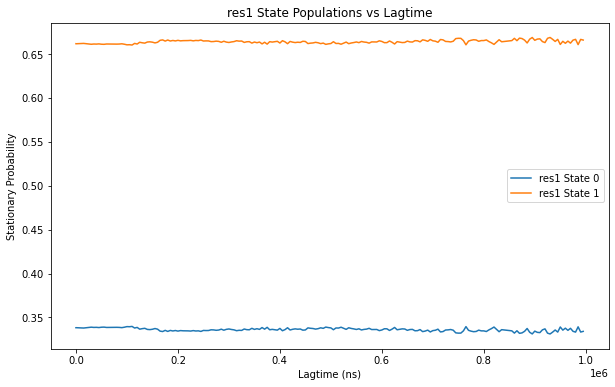

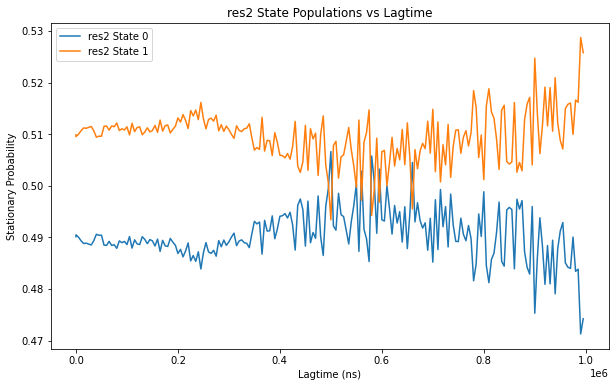

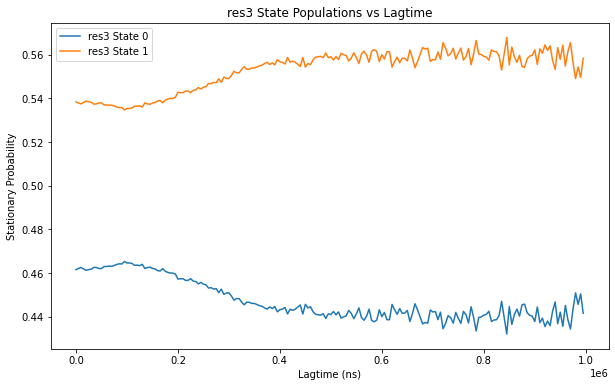

In [74]:
# For residue 1
res1_pi_state0 = residue_results['res1']['pi_means'][:, 0]  # Probability of state 0
res1_pi_state1 = residue_results['res1']['pi_means'][:, 1]  # Probability of state 1
res1_t2 = residue_results['res1']['t2_means']               # Relaxation times
lagtime_ns = lagtimes
# Plot individual residue behavior
for res_name in residue_names:
    plt.figure(figsize=(10, 6))
    plt.plot(lagtimes, residue_results[res_name]['pi_means'][:, 0], label=f'{res_name} State 0')
    plt.plot(lagtimes, residue_results[res_name]['pi_means'][:, 1], label=f'{res_name} State 1')
    plt.xlabel('Lagtime (ns)')
    plt.ylabel('Stationary Probability')
    plt.title(f'{res_name} State Populations vs Lagtime')
    plt.legend()
    plt.show()